# Desafio de Projeto: Detecção de Anomalias em Transações Financeiras
**Bootcamp Bradesco - GenAI, Dados e Cyber (DIO)**

## Objetivo do Projeto
Este projeto tem como objetivo construir um modelo de Machine Learning capaz de identificar transações fraudulentas em cartões de crédito. Trata-se de um problema clássico de **Detecção de Anomalias**, onde o principal desafio é lidar com o extremo desbalanceamento dos dados (já que fraudes são eventos muito raros).

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_curve, roc_auc_score, precision_recall_curve

# Carregando os dados originais
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)

# Verificando a proporção das classes (0 = Normal, 1 = Fraude)
print("Proporção das classes no dataset:")
print(df["Class"].value_counts(normalize=True))

Proporção das classes no dataset:
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


In [33]:
# Criando variáveis que ajudam o modelo a entender melhor a distribuição dos valores
df["Amount_log"] = np.log1p(df["Amount"])

# Padronizando a variável de valores
scaler = StandardScaler()
df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])

# Separando as variáveis preditoras (X) e a variável alvo (y)
x = df.drop("Class", axis=1)
y = df["Class"]

# Divisão em treino e teste mantendo a proporção original das classes (stratify)
x_train, x_test, y_train, y_test = train_test_split(
    x, y, stratify=y, test_size=0.3, random_state=42
)

In [34]:
from sklearn.linear_model import LogisticRegression

# Treinando o modelo base de Regressão Logística
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

# Predições e Avaliação
y_pred = model.predict(x_test)
y_probs = model.predict_proba(x_test)[:, 1]

print("--- Relatório de Classificação: Regressão Logística ---")
print(classification_report(y_test, y_pred))

/home/servidordm/.pyenv/versions/3.10.18/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- Relatório de Classificação: Regressão Logística ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.87      0.67      0.76       148

    accuracy                           1.00     85443
   macro avg       0.93      0.83      0.88     85443
weighted avg       1.00      1.00      1.00     85443



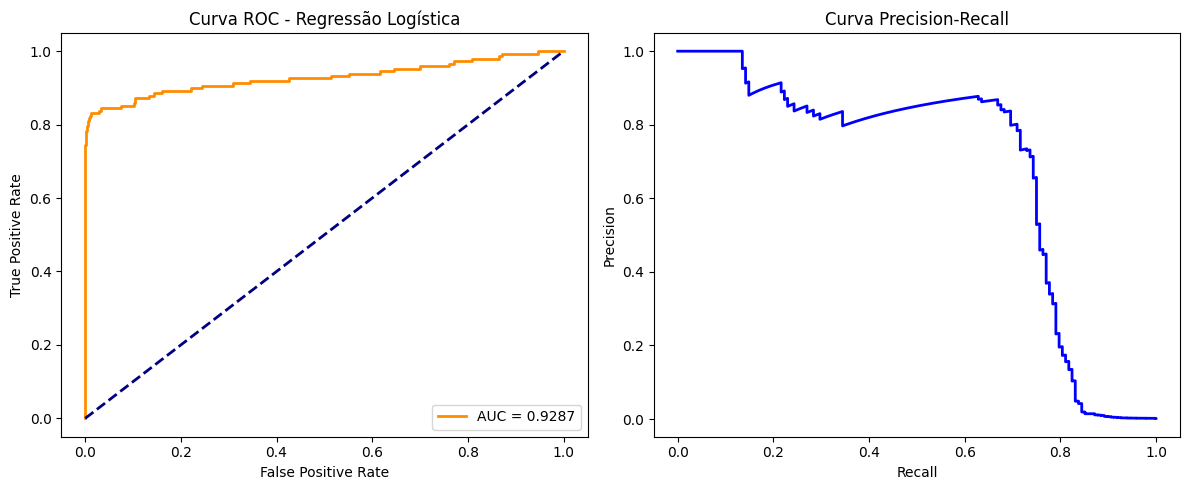

In [35]:
# Plotando a Curva ROC e calculando o AUC
fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc_score(y_test, y_probs):.4f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title("Curva ROC - Regressão Logística")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

# Plotando a Curva Precision-Recall (Mais indicada para dados desbalanceados)
precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='blue', lw=2)
plt.title("Curva Precision-Recall")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.tight_layout()
plt.show()

## Lidando com o Desbalanceamento
Como vimos que as fraudes representam menos de 0.2% dos dados, modelos tradicionais podem simplesmente ignorar a classe 1. 

Abaixo exemplificamos técnicas de Undersampling e Oversampling (SMOTE).

In [36]:
# Exemplo 1: Undersampling Manual
fraudes = df[df["Class"] == 1]
normais = df[df["Class"] == 0].sample(len(fraudes), random_state=42)
df_under = pd.concat([fraudes, normais])

# Exemplo 2: Oversampling com SMOTE (Criando dados sintéticos da classe rara)
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(x, y)

print(f"Dados originais: {x.shape[0]} amostras")
print(f"Dados após SMOTE (Oversampling): {X_res.shape[0]} amostras")

Dados originais: 284807 amostras
Dados após SMOTE (Oversampling): 568630 amostras


In [37]:
from sklearn.ensemble import RandomForestClassifier

# Criando e treinando o modelo de Random Forest com peso balanceado nas classes
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

print("--- Relatório de Classificação: Random Forest ---")
print(classification_report(y_test, y_pred_rf))

--- Relatório de Classificação: Random Forest ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.76      0.79       148

    accuracy                           1.00     85443
   macro avg       0.92      0.88      0.90     85443
weighted avg       1.00      1.00      1.00     85443



In [38]:
from xgboost import XGBClassifier

# Configurando o XGBoost com escala de peso para dados desbalanceados
xgb = XGBClassifier(
    scale_pos_weight=10, 
    eval_metric="logloss",
    random_state=42
)

xgb.fit(x_train, y_train)
y_pred_xgb = xgb.predict(x_test)

print("--- Relatório de Classificação: XGBoost ---")
print(classification_report(y_test, y_pred_xgb))

--- Relatório de Classificação: XGBoost ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.93      0.78      0.85       148

    accuracy                           1.00     85443
   macro avg       0.96      0.89      0.92     85443
weighted avg       1.00      1.00      1.00     85443



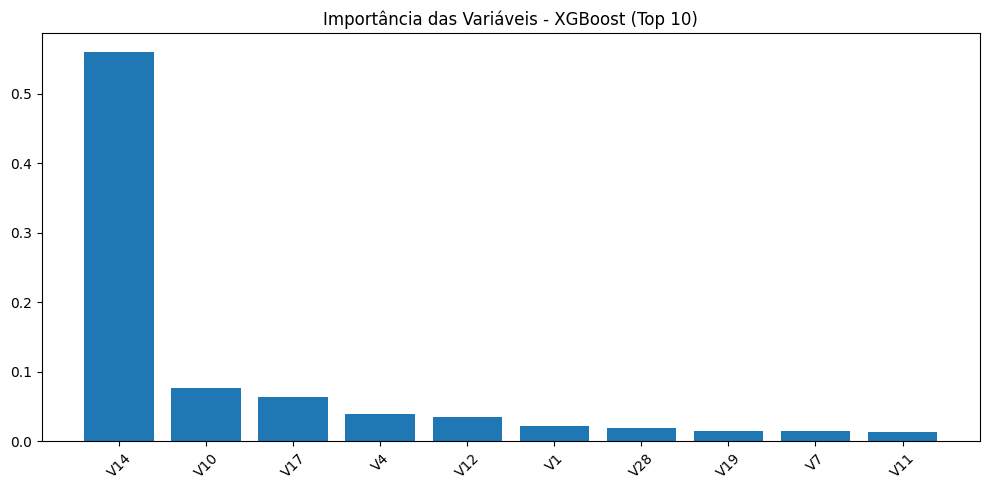

In [39]:
# Analisando quais variáveis mais influenciaram o modelo XGBoost
importancias = xgb.feature_importances_
indices = np.argsort(importancias)[::-1]

plt.figure(figsize=(10, 5))
plt.title("Importância das Variáveis - XGBoost (Top 10)")
plt.bar(range(10), importancias[indices[:10]], align="center")
plt.xticks(range(10), x.columns[indices[:10]], rotation=45)
plt.tight_layout()
plt.show()

PermutationExplainer explainer: 51it [00:12,  1.35s/it]                                                                               


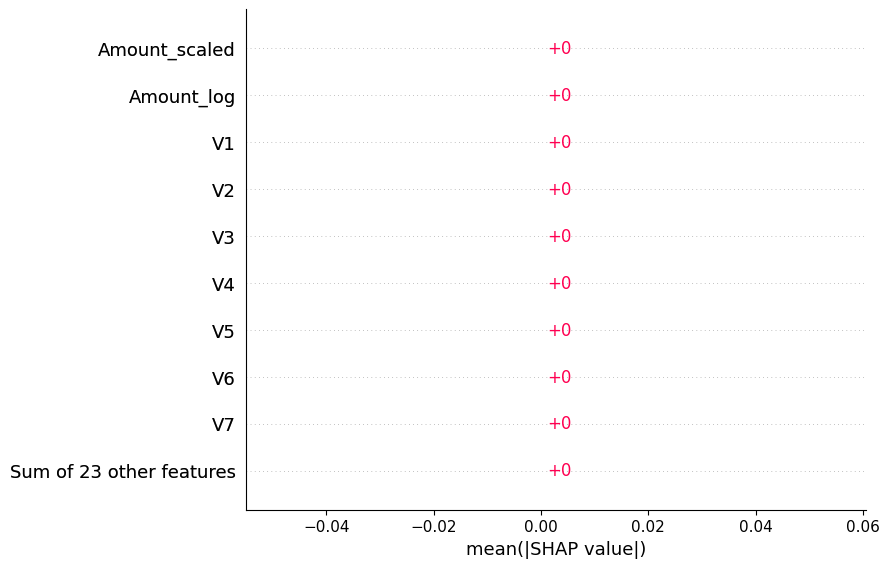

In [40]:
import shap

# Inicializando o Explainer usando a função de predição matemática do XGBoost
# Isso evita erros de leitura na conversão de strings da árvore do XGBoost v3
explainer = shap.Explainer(xgb.predict, x_train, algorithm="permutation")

# Calculando os valores SHAP para as primeiras 50 transações do conjunto de teste
shap_values = explainer(x_test[:50])

# Gerando o gráfico de barras global de impacto das variáveis
shap.plots.bar(shap_values)

## Conclusão do Projeto

Após a análise e teste de múltiplos algoritmos para a detecção de fraude, podemos concluir:
1. **Regressão Logística:** Rápida, mas apresentou o menor *Recall* (0.68), deixando passar muitas fraudes.
2. **Random Forest:** Teve um bom equilíbrio e elevou o *Recall* para 0.76.
3. **XGBoost:** Mostrou-se o modelo mais robusto, alcançando a maior **Precisão (0.93)** e um **Recall elevado (0.78)**. Em sistemas de fraude, ele minimiza falsos alarmes (evitando bloquear cartões de clientes legítimos) enquanto captura a grande maioria das transações suspeitas.

O uso do **SHAP** nos permitiu entender quais recursos específicos das transações (especialmente os componentes principais calculados) mais pesam na decisão de classificar uma movimentação como anomalia.